# LEO/VLEO Pass Analysis — 250km VLEO, Northwest Spain Ground Station

Simulation of a complete satellite pass over Northwest Spain Ground Station (42.24°N, 8.72°W) at 250km VLEO altitude.

The notebook computes pass geometry, Doppler shift and link margin second by second,
and validates the results against STK Enterprise orbital propagator.

**Key findings:**
- Zenith pass assumption: max elevation 90°, Doppler ±14 kHz, duration ~468s
- STK real geometry (Pass 2): max elevation 36.9°, Doppler ±49 kHz, duration ~465s
- Doppler rate at zenith: ~60 Hz/s (simulator) vs ~700 Hz/s (STK)
- **Worst case for PLL design is the rasante pass, not the zenith pass**

**Configuration:** LEO pessimist — 1W TX, 6 dBi satellite antenna, 20 dBi ground station, S-band 2 GHz

In [1]:
import plotly.io as pio
pio.renderers.default = "png"
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from src.run_satellite import run_satellite
from src.utils.geometry.orbital.orbital_angular_speed import orbital_angular_speed
from src.utils.geometry.orbital.orbital_radius import orbital_radius
from src.utils.geometry.orbital.pass_duration import pass_duration
from src.utils.geometry.orbital.max_central_angle import max_central_angle
from src.utils.geometry.orbital.elevation_vs_time import elevation_vs_time
from src.utils.geometry.orbital.doppler import doppler
from src.utils.geometry.orbital.diff_doppler import diff_doppler
from params.LEO_VLEO_pesimistic_config import leo_pessimist_config
from src.utils.input.comparation_vs_stk import comparation_vs_stk
from src.utils.input.STK_doppler import STK_doppler

## 1. Orbital Geometry

Compute the basic orbital parameters for a 250km circular orbit.

- **Orbital radius** `r`: distance from Earth center to satellite (Earth radius + altitude)
- **Angular speed** `ω`: how fast the satellite moves along its orbit (rad/s)
- **Max central angle** `δ_max`: maximum angle Earth-center subtended during the pass, for a minimum elevation of 5°
- **Pass duration** `T`: time the satellite is above 5° elevation — operational window
- **Pass duration** `T_0`: theoretical maximum pass duration at 0° elevation — used to centre the time vector

In [2]:

r = orbital_radius(250,leo_pessimist_config.terrestrial_radio_Km)
omega = orbital_angular_speed(r)
delta_max = max_central_angle(5,r,leo_pessimist_config.terrestrial_radio_Km)
T = pass_duration(delta_max, omega)
T_0 = pass_duration(max_central_angle(0, r, leo_pessimist_config.terrestrial_radio_Km), omega)

## 2. Dynamic Pass Computation

Compute elevation angle and slant range second by second during the pass.

`elevation_vs_time` uses the law of cosines on the Earth-center/ground-station/satellite triangle
to compute the slant range and elevation at each time step.

`run_satellite` computes the link margin at each instant using the dynamic slant range —
FSPL increases as the satellite moves away from zenith, reducing the link margin.


In [3]:
[t_sim,slant_delta_sim, el_sim] = elevation_vs_time(T_0,omega,r,leo_pessimist_config.terrestrial_radio_Km)
[margin_vs_t, value0, rx_power] = run_satellite(leo_pessimist_config,None,slant_delta_sim,2000,el_sim,False)

## 3. STK Validation Data

Load real orbital propagator data from STK Enterprise for the same scenario:
- Facility1: Vigo, 42.24°N, 8.72°W
- Satellite1: 250km altitude, 97° inclination, Two-Body propagator
- Pass 2 selected: best pass over Vigo, max elevation 36.9°, duration ~465s

STK data is used to validate both elevation profile and Doppler shift
against the simulator's zenith pass assumption.

## 4. Doppler Analysis

Compute Doppler shift and Doppler rate for both simulator and STK.

**Simulator Doppler** assumes a zenith pass — the satellite passes directly overhead,
so the radial velocity component is purely tangential at the edges and zero at zenith.
Result: ±14 kHz, smooth symmetric curve.

**STK Doppler** is derived from the range rate (km/s) exported from the propagator:
f_doppler (kHz) = -(f_MHz × 1e3 × range_rate) / 3e5

Sign inverted: negative range rate (approaching) → positive Doppler shift.
Result: ±49 kHz, pronounced S-curve — the satellite approaches nearly head-on.

**Doppler rate** (Hz/s) is computed as the numerical derivative of the Doppler curve.
This is the key parameter for PLL design — how fast the receiver must track the frequency.

In [4]:
[t_stk,el_stk] = comparation_vs_stk()
[t_doppler_stk, RangeRate_stk ] = STK_doppler()
f_doppler_STK_kHz = -(2000 * 1e3 * RangeRate_stk) / 3e5
f_doppler = doppler(2000,omega,r, t_sim)
t_sim_shifted = t_sim - t_sim[0]
doppler_variation = diff_doppler(f_doppler,t_sim_shifted)
doppler_variation_STK = diff_doppler(f_doppler_STK_kHz,t_doppler_stk.values)

## 5. Simulator Scenario — Complete Pass

Four-panel plot showing the complete pass geometry and RF analysis from the simulator:

1. **Elevation vs time** — rises from 0° to 90° at zenith, symmetric
2. **Slant range vs time** — minimum at zenith (250km), maximum at horizon (~1330km)
3. **Doppler shift vs time** — ±14 kHz, crosses zero at zenith
4. **Doppler rate vs time** — ~60 Hz/s peak at zenith, nearly constant (zenith pass characteristic)

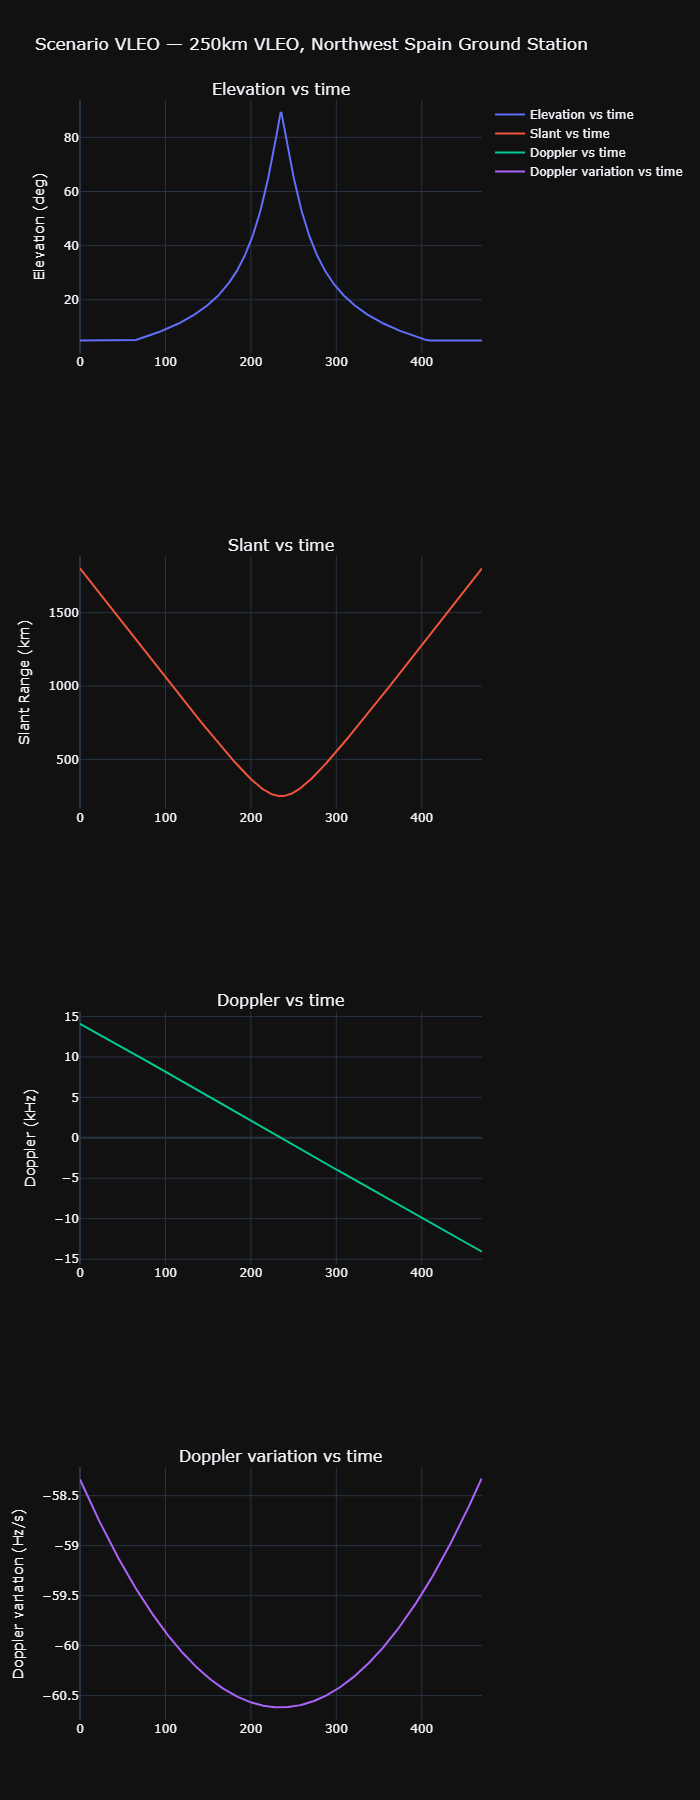

In [5]:
fig = make_subplots(rows=4, cols=1,
                    subplot_titles=('Elevation vs time', 'Slant vs time','Doppler vs time','Doppler variation vs time'))

# First plot  —
fig.add_trace(go.Scatter(x=t_sim_shifted, y=el_sim, name='Elevation vs time'), row=1, col=1)


# Second plot  —
fig.add_trace(go.Scatter(x=t_sim_shifted, y=slant_delta_sim, name='Slant vs time'), row=2, col=1)

# Third plot  —
fig.add_trace(go.Scatter(x=t_sim_shifted, y=f_doppler, name='Doppler vs time'), row=3, col=1)

# Fourth plot  —
fig.add_trace(go.Scatter(x=t_sim_shifted, y=doppler_variation, name='Doppler variation vs time'), row=4, col=1)

fig.update_yaxes(title_text="Elevation (deg)", row=1, col=1)
fig.update_yaxes(title_text="Slant Range (km)", row=2, col=1)
fig.update_yaxes(title_text="Doppler (kHz)", row=3, col=1)
fig.update_yaxes(title_text="Doppler variation (Hz/s)", row=4, col=1)

fig.update_layout(title='Scenario VLEO — 250km VLEO, Northwest Spain Ground Station',height=1800)
fig.show()


## 6. STK vs Simulator — Elevation Comparison

Two-panel comparison of elevation profiles:

- **Absolute elevation**: STK max 36.9° vs simulator 90° — different geometry, not an error
- **Normalized elevation**: both curves peak at 1.0 — shape is consistent, confirming
  the simulator correctly models the geometry for its assumed pass type

The difference is explained by the pass geometry: the simulator assumes a zenith pass
(satellite passes directly overhead) while STK Pass 2 is a rasante pass
(satellite passes at low elevation on the horizon).


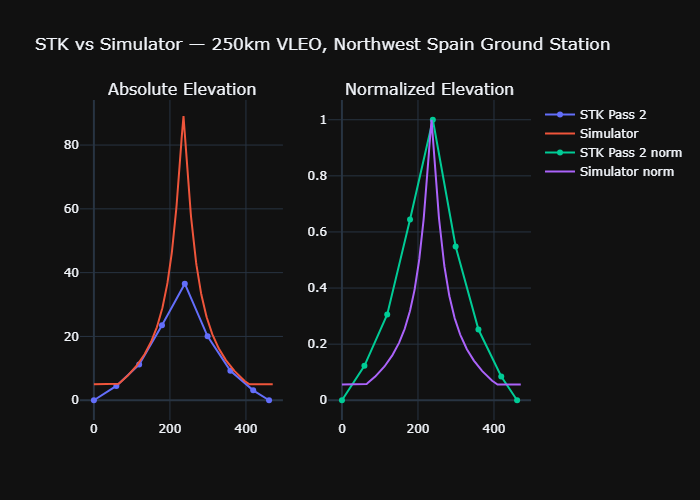

In [6]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Absolute Elevation', 'Normalized Elevation'))

# Left plot  — absolut values
fig.add_trace(go.Scatter(x=t_stk, y=el_stk, name='STK Pass 2'), row=1, col=1)
fig.add_trace(go.Scatter(x=t_sim_shifted, y=el_sim, name='Simulator'), row=1, col=1)

# Right plot  — normalized
fig.add_trace(go.Scatter(x=t_stk, y=el_stk/el_stk.max(), name='STK Pass 2 norm'), row=1, col=2)
fig.add_trace(go.Scatter(x=t_sim_shifted, y=el_sim/el_sim.max(), name='Simulator norm'), row=1, col=2)

fig.update_layout(title='STK vs Simulator — 250km VLEO, Northwest Spain Ground Station')
fig.show()

## 7. STK vs Simulator — Doppler Analysis

Two-panel comparison of Doppler shift and Doppler rate:

**Doppler shift:**
- Simulator: ±14 kHz — zenith pass, low radial velocity component
- STK: ±49 kHz — rasante pass, satellite approaches nearly head-on maximising radial velocity
- Both curves cross zero at zenith (cénit) — consistent behaviour

**Doppler rate:**
- Simulator: ~60 Hz/s — nearly flat, zenith pass has gradual Doppler variation
- STK: ~700 Hz/s peak at zenith — rasante pass changes Doppler very rapidly near zenith

**Conclusion:** the rasante pass is the worst case for PLL design.
A receiver designed only for the zenith case would lose lock during a real rasante pass.

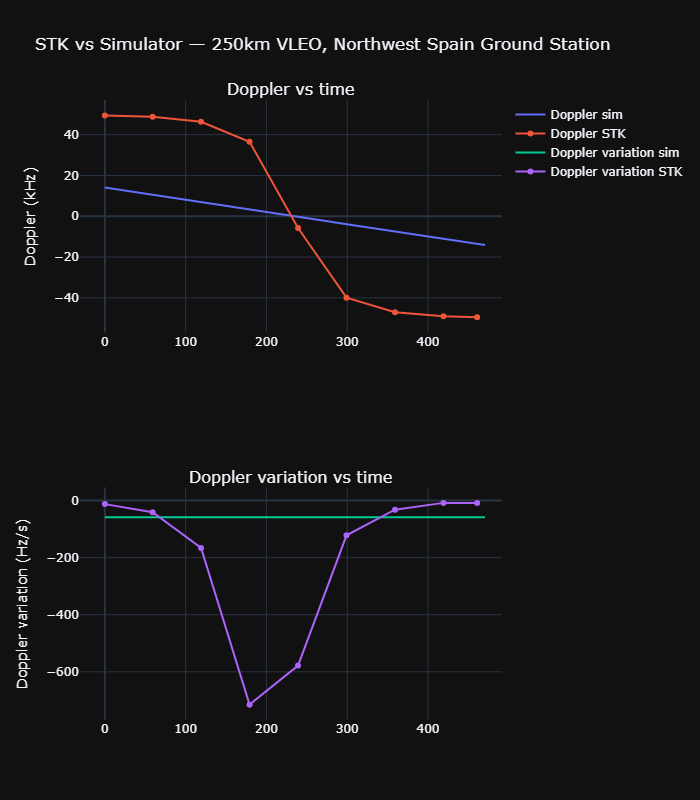

In [7]:

fig = make_subplots(rows=2, cols=1,
                    subplot_titles=('Doppler vs time', 'Doppler variation vs time'))
fig.add_trace(go.Scatter(x=t_sim_shifted, y=f_doppler, name='Doppler sim'),row=1,col=1)
fig.add_trace(go.Scatter(x=t_stk, y=f_doppler_STK_kHz, name='Doppler STK'),row=1,col=1)

fig.add_trace(go.Scatter(x=t_sim_shifted, y=doppler_variation, name='Doppler variation sim'),row=2,col=1)
fig.add_trace(go.Scatter(x=t_stk, y=doppler_variation_STK, name='Doppler variation STK'),row=2,col=1)
fig.update_yaxes(title_text="Doppler (kHz)", row=1, col=1)
fig.update_yaxes(title_text="Doppler variation (Hz/s)", row=2, col=1)
fig.update_layout(title='STK vs Simulator — 250km VLEO, Northwest Spain Ground Station',height=800)
fig.show()



## 8. Link Margin During Pass

Link margin computed second by second during the zenith pass.

- **Positive margin**: sufficient signal level, link is viable
- **Zero crossing**: coverage threshold — link margin = 0 dB
- **Negative margin**: insufficient signal, link breaks

Expected behaviour: maximum margin at zenith (minimum slant range = 250km, minimum FSPL),
decreasing towards the horizon as slant range increases to ~1330km.

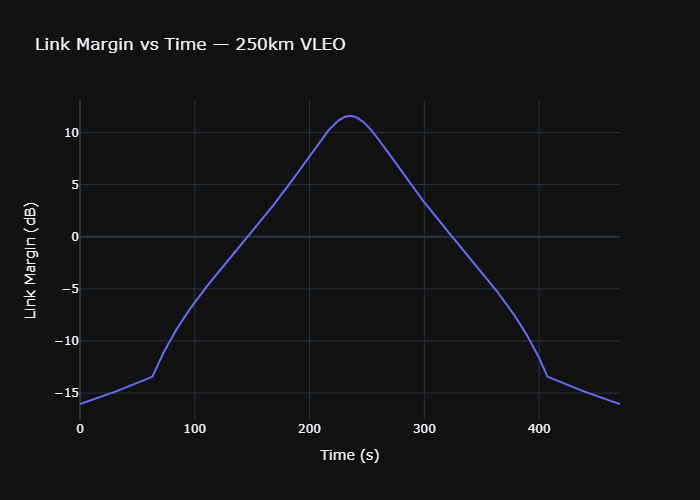

In [8]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=t_sim_shifted,
    y=margin_vs_t,
    name='Link Margin'
))

fig.update_layout(
    title='Link Margin vs Time — 250km VLEO',
    xaxis_title='Time (s)',
    yaxis_title='Link Margin (dB)'
)

fig.show()